# This code is meant to replace the combination of LAHM_analysis & LAHM_analysis_analytical

April 2021

In [1]:
# Generic resources
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
from scipy import optimize

# Local imports
import LAHM_library as LL

In [2]:
%matplotlib inline
%pwd

'/home/chemistry/LAHM'

In [3]:
# Instrument factors
myLAHM_Parameters = LL.LAHM_Parameters(inst_number = 10) # 20 is for Lucy's LAHM
myLAHM_Parameters.report()

Parameters:
LAHM unit = 10
inst_factor = 0.77
exponential_prefactor = 3.43
temperature_factor = 0.238
ugbasic_offset = 3.0


In [4]:
# Graphics parameters
figwidth = 25
figheight = 12
fontsize = 12

In [5]:
# Folder name
foldername = 'Cascades (UCB UCB UPS)/'; filelist = 'filelist_Rainier.txt'
# foldername = 'Cascades (UCB UCB UPS)/'; filelist = 'filelist_Baker.txt'
# foldername = 'Cascades (UCB UPS UPS)/'; filelist = 'filelist_Baker.txt'
# foldername = 'Cascades (UCB UCB UPS)/'; filelist = 'filelist_Adams.txt'
# foldername = 'Cascades (UCB UCB UPS)/'; filelist = 'filelist_Columbia.txt'
# foldername = 'LAHM Data Summer 2025/'; filelist = 'filelist.txt'
# foldername = 'Cascades (UCB UPS UPS)/'; filelist = 'filelist_Rainier.txt'


# Not sure about the status of these 
# foldername = 'Cascades_measured_at_PS/Trial_runs/'
# foldername = 'Cascades (UCB/UPS/UPS)/Trial runs/'

In [6]:
# Name of the master file with all the filenames and the volumes
filename = foldername+filelist

In [7]:
# Read in the master file
line0_list, number = LL.getline0list(filename)
print('number = ', number)
for i in range(number):
    line0_list[i] = foldername+line0_list[i]
    print(line0_list[i])

Cascades (UCB UCB UPS)/filelist_Rainier.txt
number =  7
Cascades (UCB UCB UPS)/2024/rainier_camp_subsurface_8syringes.txt 480
Cascades (UCB UCB UPS)/2024/rainier_camp_surface_8syringes.txt 480
Cascades (UCB UCB UPS)/2025/July_2025/rainiermuir_july13_2025_1syringe.txt 60
Cascades (UCB UCB UPS)/2025/June_2025/rainier_summit_june25_2025_5.6syringes.txt 336
Cascades (UCB UCB UPS)/2025/July_2025/rainieringrahamflats_july13_2025_1syringe.txt 60
Cascades (UCB UCB UPS)/2025/May_2025/rainier_campmuir_may23_2025_4.8syringes.txt 288
Cascades (UCB UCB UPS)/2025/May_2025/rainier_highcamp_may23_2025_3.75syringes.txt 225


In [8]:
# Run the original Schmitt analysis
myTtrace_list = LL.getgpg(line0_list, myLAHM_Parameters,verbose=True)
for i in range(0,number):
    print('')
    print('Working on i = ', i)
    myTtrace = myTtrace_list[i]
    myTtrace.report()

From getgpg: number =  7
From getgpg: t =  0
From getgpg:  ['Cascades', '(UCB', 'UCB', 'UPS)/2024/rainier_camp_subsurface_8syringes.txt', '480']
From getgpg: filename2 =  Cascades (UCB UCB UPS)/2024/rainier_camp_subsurface_8syringes.txt
From getgpg: vol[t] =  480.0
From getgpg: t =  1
From getgpg:  ['Cascades', '(UCB', 'UCB', 'UPS)/2024/rainier_camp_surface_8syringes.txt', '480']
From getgpg: filename2 =  Cascades (UCB UCB UPS)/2024/rainier_camp_surface_8syringes.txt
From getgpg: vol[t] =  480.0
From getgpg: t =  2
From getgpg:  ['Cascades', '(UCB', 'UCB', 'UPS)/2025/July_2025/rainiermuir_july13_2025_1syringe.txt', '60']
From getgpg: filename2 =  Cascades (UCB UCB UPS)/2025/July_2025/rainiermuir_july13_2025_1syringe.txt
From getgpg: vol[t] =  60.0
From getgpg: t =  3
From getgpg:  ['Cascades', '(UCB', 'UCB', 'UPS)/2025/June_2025/rainier_summit_june25_2025_5.6syringes.txt', '336']
From getgpg: filename2 =  Cascades (UCB UCB UPS)/2025/June_2025/rainier_summit_june25_2025_5.6syringes.txt


Cascades (UCB UCB UPS)/2024/rainier_camp_subsurface_8syringes.txt
Cascades (UCB UCB UPS)/2024/rainier_camp_surface_8syringes.txt
Cascades (UCB UCB UPS)/2025/July_2025/rainiermuir_july13_2025_1syringe.txt
Cascades (UCB UCB UPS)/2025/June_2025/rainier_summit_june25_2025_5.6syringes.txt
Cascades (UCB UCB UPS)/2025/July_2025/rainieringrahamflats_july13_2025_1syringe.txt
Cascades (UCB UCB UPS)/2025/May_2025/rainier_campmuir_may23_2025_4.8syringes.txt
Cascades (UCB UCB UPS)/2025/May_2025/rainier_highcamp_may23_2025_3.75syringes.txt


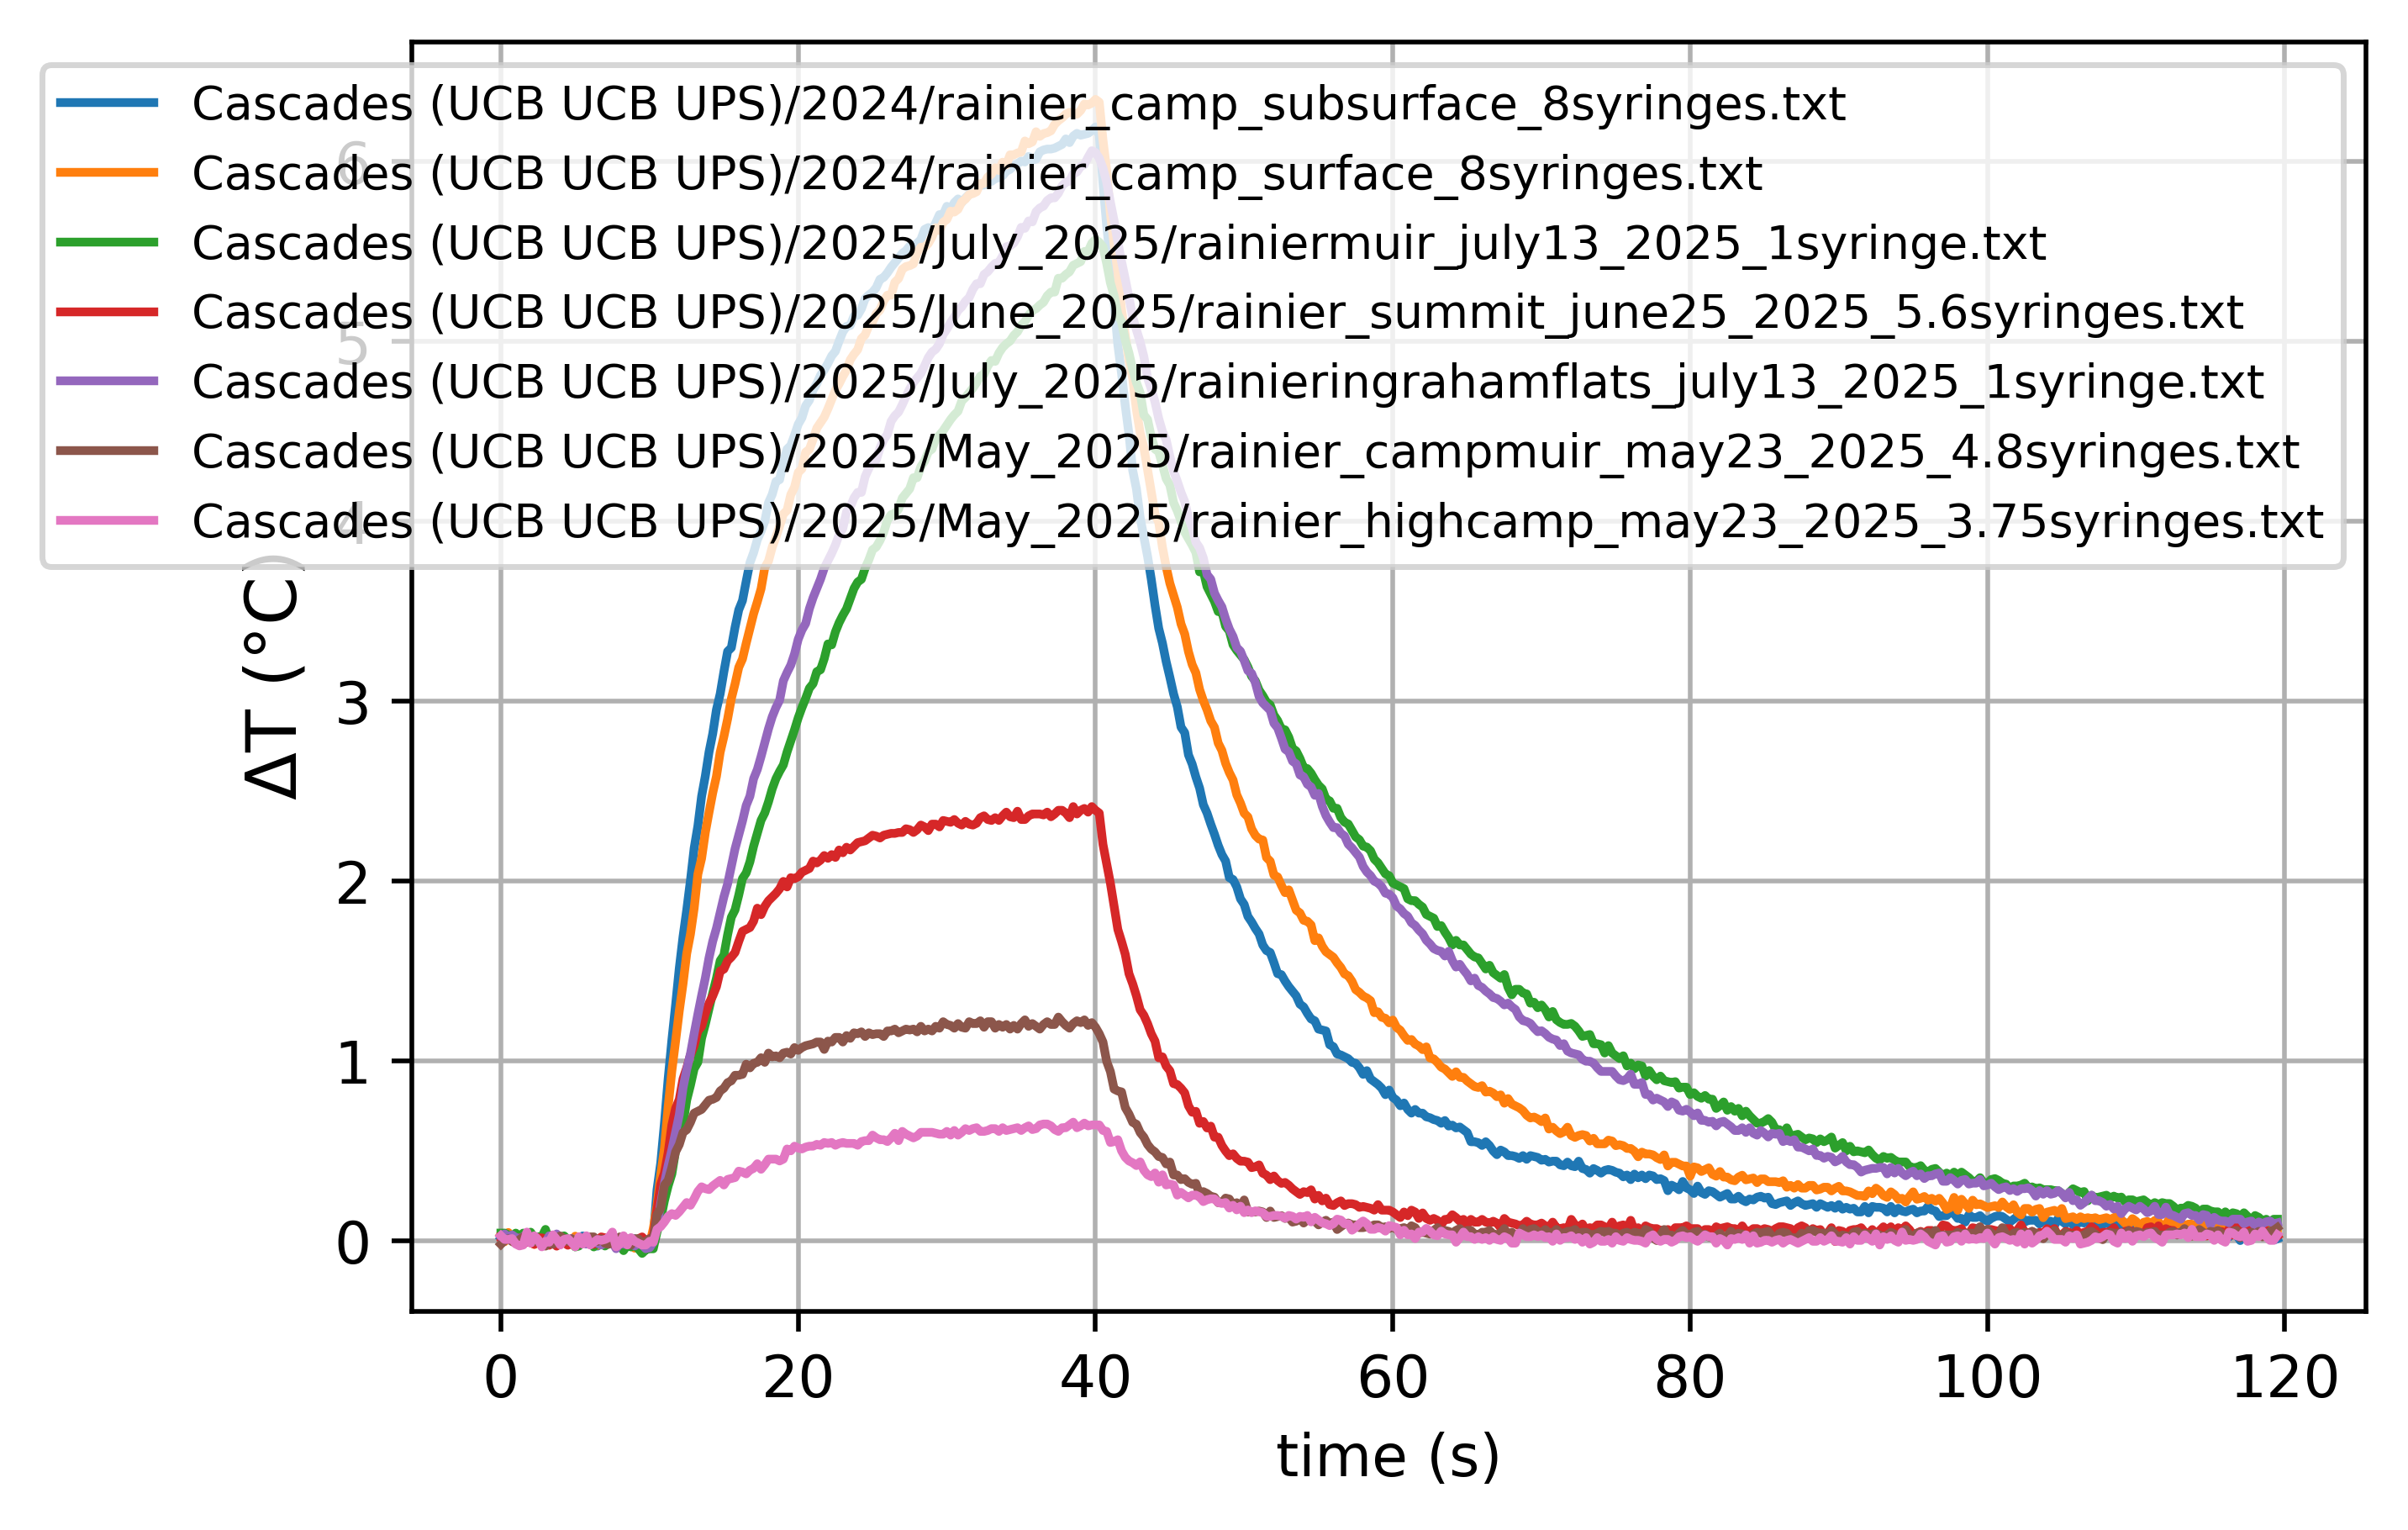

In [9]:
# Makes heating curve/Mean Temp Increase graph
# Plot all the traces
# plt.figure(figsize=(figwidth, figheight))
plt.figure(dpi=500)
mylabel_List = []
for i in range(number): 
    myTtrace = myTtrace_list[i]
   # mylabel = myTtrace.filename+', '+str(myTtrace.ugbasic)[0:4]+'$\ \mu g$'+', '+str(myTtrace.volume)[0:4]+' mL'
    mylabel = myTtrace.filename
    print(mylabel)
    mylabel_List.append(mylabel)
    plt.plot(myTtrace.time, myTtrace.Temp_av, label=mylabel) 
#plt.ylabel('Mean temp increase ($^\circ$C)')
plt.ylabel(r'$\Delta$T ($\degree$C)',fontsize=fontsize)
plt.xlabel('time (s)')
plt.legend(loc='upper right',fontsize=8)
plt.grid(True)
plt.show()

In [10]:
#makes Delta T graph
## Loops through file list and graphs
#True = want to see every graph
graphs = False

A_array = np.zeros(number)
t0_array = np.zeros(number)
A1_array = np.zeros(number)
t01_array = np.zeros(number)
A2_array = np.zeros(number)
t02_array = np.zeros(number)
theorylabel_List = []
plt.figure(dpi=500)

for i in range(number):

    print('')
    print('Working on i = ', i)

    myTtrace = myTtrace_list[i]
    myTtrace.report()
    
    # Extract from when it starts to rise
    Temp_expt = myTtrace.Temp_av[40:160]
    time_expt = myTtrace.time[40:160]-myTtrace.time[40]

    # Do a 2-parameter fit
    params, params_covariance = optimize.curve_fit(LL.test_func, time_expt, Temp_expt, p0=[2, 3])
    A_array[i]=params[0]
    t0_array[i]=params[1]

    # # Do a 4-parameter fit
    # params2, params2_covariance = optimize.curve_fit(test_func2, time_expt, Temp_expt, p0=[2, 5, 2 ,5], bounds=(0, 100))
    # A1_array[i]=params2[0]
    # t01_array[i]=params2[1]
    # A2_array[i]=params2[2]
    # t02_array[i]=params2[3]

    if graphs:
        theory = LL.test_func(time_expt,params[0],params[1])
        # theory2 = LL.test_func2(time_expt,params2[0],params2[1],params2[2],params2[3])
        exptlabel = mylabel_List[i]

        # plt.figure(dpi=200)
        plt.plot(time_expt,Temp_expt,'+',label=exptlabel)
        theorylabel = '$A(1-e^{-t/t_0})$'+'  A='+str(params[0])[0:6]+'  t0='+str(params[1])[0:6]
        print(theorylabel)
        theorylabel_List.append(theorylabel)
        plt.plot(time_expt,theory, color= 'black')
        # plt.plot(time_expt,theory2, color= 'black',alpha=.5)
        plt.ylabel(r'$\Delta$T ($\degree$C)',fontsize=fontsize)
        plt.xlabel('time (s)')
        plt.legend()
        plt.grid(True)
plt.show()


Working on i =  0
Cascades (UCB UCB UPS)/2024/rainier_camp_subsurface_8syringes.txt 480.0 24.95112807129709 11.976541474222605

Working on i =  1
Cascades (UCB UCB UPS)/2024/rainier_camp_surface_8syringes.txt 480.0 26.10656355721235 12.531150507461929

Working on i =  2
Cascades (UCB UCB UPS)/2025/July_2025/rainiermuir_july13_2025_1syringe.txt 60.0 165.07201570617573 9.904320942370545

Working on i =  3
Cascades (UCB UCB UPS)/2025/June_2025/rainier_summit_june25_2025_5.6syringes.txt 336.0 9.118478378179185 3.063808735068206

Working on i =  4
Cascades (UCB UCB UPS)/2025/July_2025/rainieringrahamflats_july13_2025_1syringe.txt 60.0 191.26895685756924 11.476137411454154

Working on i =  5
Cascades (UCB UCB UPS)/2025/May_2025/rainier_campmuir_may23_2025_4.8syringes.txt 288.0 5.3845963414253974 1.5507637463305146

Working on i =  6
Cascades (UCB UCB UPS)/2025/May_2025/rainier_highcamp_may23_2025_3.75syringes.txt 225.0 4.440074986428543 0.9990168719464223


<Figure size 3000x2000 with 0 Axes>

### Below is a listing of three main parameters
Loading in $\micro$ grams, loading in ${ng \over g}$, $t_0$, 

### Notice!
The numbers below are what we are focusing on. After that are diagnostic tests.

In [11]:
print('')
print('file, ugbasic, ngperg, t0')
for i in range(number):
    ugbasic = myTtrace_list[i].ugbasic
    ngperg = myTtrace_list[i].ngperg
    t0 = t0_array[i]
    myTtrace = myTtrace_list[i]
    mylabel = myTtrace_list[i].filename
    print(mylabel,ugbasic,ngperg,t0)


file, ugbasic, ngperg, t0
Cascades (UCB UCB UPS)/2024/rainier_camp_subsurface_8syringes.txt 11.976541474222605 24.95112807129709 7.3911149106287395
Cascades (UCB UCB UPS)/2024/rainier_camp_surface_8syringes.txt 12.531150507461929 26.10656355721235 9.324023467219819
Cascades (UCB UCB UPS)/2025/July_2025/rainiermuir_july13_2025_1syringe.txt 9.904320942370545 165.07201570617573 18.61652451456669
Cascades (UCB UCB UPS)/2025/June_2025/rainier_summit_june25_2025_5.6syringes.txt 3.063808735068206 9.118478378179185 5.007323100273204
Cascades (UCB UCB UPS)/2025/July_2025/rainieringrahamflats_july13_2025_1syringe.txt 11.476137411454154 191.26895685756924 15.899266360025571
Cascades (UCB UCB UPS)/2025/May_2025/rainier_campmuir_may23_2025_4.8syringes.txt 1.5507637463305146 5.3845963414253974 3.882034286061558
Cascades (UCB UCB UPS)/2025/May_2025/rainier_highcamp_may23_2025_3.75syringes.txt 0.9990168719464223 4.440074986428543 6.6879746443139805


In [12]:
# # writes data into output.txt file
# f2 = open('output.txt', 'w')
# #header
# f2.write('file         \t \t A \t   t0\n')

# # write the data as float values with a tab between them
# for i in range(number):
#     f2.write('%s    %f    %f\n' % (myTtrace_list[i].filename, A_array[i],t0_array[i]))

# f2.close()

In [13]:
# Copy micrograms into a new array "microg" from myTtrace_List
microg = np.zeros(number)
for i in range(number):
    print(myTtrace_list[i].ugbasic)
    microg[i] = myTtrace_list[i].ugbasic

# Print in the order they come
print("microg before sorting = ",microg)

# Find the indices of the microgram array in ascending order
sort_index = np.argsort(microg); print('Microgram indices in increasing order =', sort_index)

# Make new arrays of Schmitt's micrograms and A-values, in ascending order of micrograms
microg_sorted = microg[sort_index]; print("microg after sorting = ",microg_sorted)
A_array_sorted = A_array[sort_index]; print("A-values after sorting = ",A_array_sorted)

11.976541474222605
12.531150507461929
9.904320942370545
3.063808735068206
11.476137411454154
1.5507637463305146
0.9990168719464223
microg before sorting =  [11.97654147 12.53115051  9.90432094  3.06380874 11.47613741  1.55076375
  0.99901687]
Microgram indices in increasing order = [6 5 3 2 4 0 1]
microg after sorting =  [ 0.99901687  1.55076375  3.06380874  9.90432094 11.47613741 11.97654147
 12.53115051]
A-values after sorting =  [0.64000945 1.19063864 2.3696434  6.89940952 7.09544568 6.16783687
 6.48724699]


7
fit order =  2
p =  [-0.09174968  2.49350187 -1.20033052]


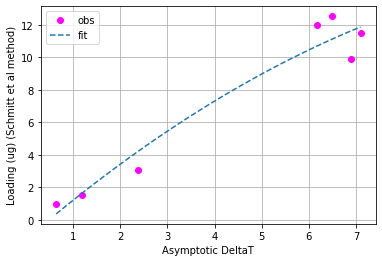

t0 ranges from  3.882034286061558 18.61652451456669


In [14]:
# Examining correlation between A and Schmitt's micrograms
print(number)
if number > 2: 
    
    # Plot A values as a function of Schmitt's values
    # plt.figure(figsize=(figwidth, figheight))
    plt.figure()
    plt.plot(A_array_sorted, microg_sorted, 'o', color= 'magenta', label='obs')
    plt.grid(True)
    
    # Do a fit
    maxorder = 2
    if number > 2:
        fit_order = np.min((maxorder,number)); print('fit order = ',fit_order)
        p = np.polyfit(A_array_sorted, microg_sorted, fit_order); print('p = ',p)
        A_dense = np.linspace(np.min(A_array), np.max(A_array))
        microg_polyval = np.polyval(p, A_dense)
        plt.plot(A_dense, microg_polyval, '--',label='fit')
        plt.ylabel('Loading (ug) (Schmitt et al method)') 
        plt.xlabel('Asymptotic DeltaT')
    plt.legend()
    plt.show()
    
    print('t0 ranges from ', np.min(t0_array),np.max(t0_array))

In [15]:
#making sure we aren't crazy
print(A_array_sorted)
print('i  loading from A  Schmitts loading')

if number > 2:
    LoadingFromA = p[2] + p[1]* A_array_sorted + p[0]*A_array_sorted**2
    for i in range(number):
        print(i, LoadingFromA[i], microg_sorted[i])
    # loading as calculated from A and Schmitt's loading agree, telling us that asymptotic A is a good proxy for t[160] (see LAHM_library) for the same material

[0.64000945 1.19063864 2.3696434  6.89940952 7.09544568 6.16783687
 6.48724699]
i  loading from A  Schmitts loading
0 0.3579524707355979 0.9990168719464223
1 1.6384629455723063 1.5507637463305146
2 4.193186047459968 3.063808735068206
3 11.635905445753993 9.904320942370545
4 11.873006946760214 11.476137411454154
5 10.68882157482378 11.976541474222605
6 11.11440425774848 12.531150507461929


fit order =  2
p =  [-0.0638587   1.3927964  -0.88606574]


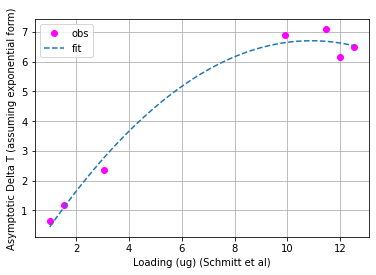

t0 ranges from  3.882034286061558 18.61652451456669


In [16]:
# Examining correlation between A and Schmitt's micrograms

if number > 2: 
    
    # Plot A values as a function of Schmitt's values
    # plt.figure(figsize=(figwidth, figheight))
    plt.plot(microg_sorted, A_array_sorted,'o', color= 'magenta', label='obs')
    plt.grid(True)
    
    # Do a fit
    maxorder = 2
    if number > 2:
        fit_order = np.min((maxorder,number)); print('fit order = ',fit_order)
        p = np.polyfit(microg_sorted, A_array_sorted,fit_order); print('p = ',p)
        microg_dense = np.linspace(np.min(microg),np.max(microg))
        A_polyval = np.polyval(p,microg_dense)
        plt.plot(microg_dense,A_polyval,'--',label='fit')
        plt.xlabel('Loading (ug) (Schmitt et al)') 
        plt.ylabel('Asymptotic Delta T (assuming exponential form)')
    plt.legend()
    plt.show()
    
    print('t0 ranges from ', np.min(t0_array),np.max(t0_array))